# Análisis Exploratorio de Datos

26 de Marzo de 2026

Trabajaremos **en clases** el ejemplo con la base de datos de sobrevivientes de Titanic de [Kaggle](https://www.kaggle.com/competitions/titanic). Debe responder todas las preguntas que están en el notebook (con **negrita**).



## Introducción
Antes de cualquier intento de predicciones usando algoritmos de ML, debemos tratar de entender "lo que nos dicen los datos". Para esto, realizamos un análisis de datos exploratorio (EDA en inglés). El EDA es un enfoque para analizar conjuntos de datos que busca resumir sus características principales, a menudo con métodos visuales.
Es el primer paso en cualquier análisis de datos y ayuda a descubrir patrones, detectar anomalías, probar hipótesis y verificar suposiciones. Al explorar los datos, los analistas pueden tomar decisiones informadas sobre qué variables incluir en los modelos y cómo preprocesarlas. Además, permite la selección de métodos de análisis adecuados y la formulación de preguntas de investigación relevantes.


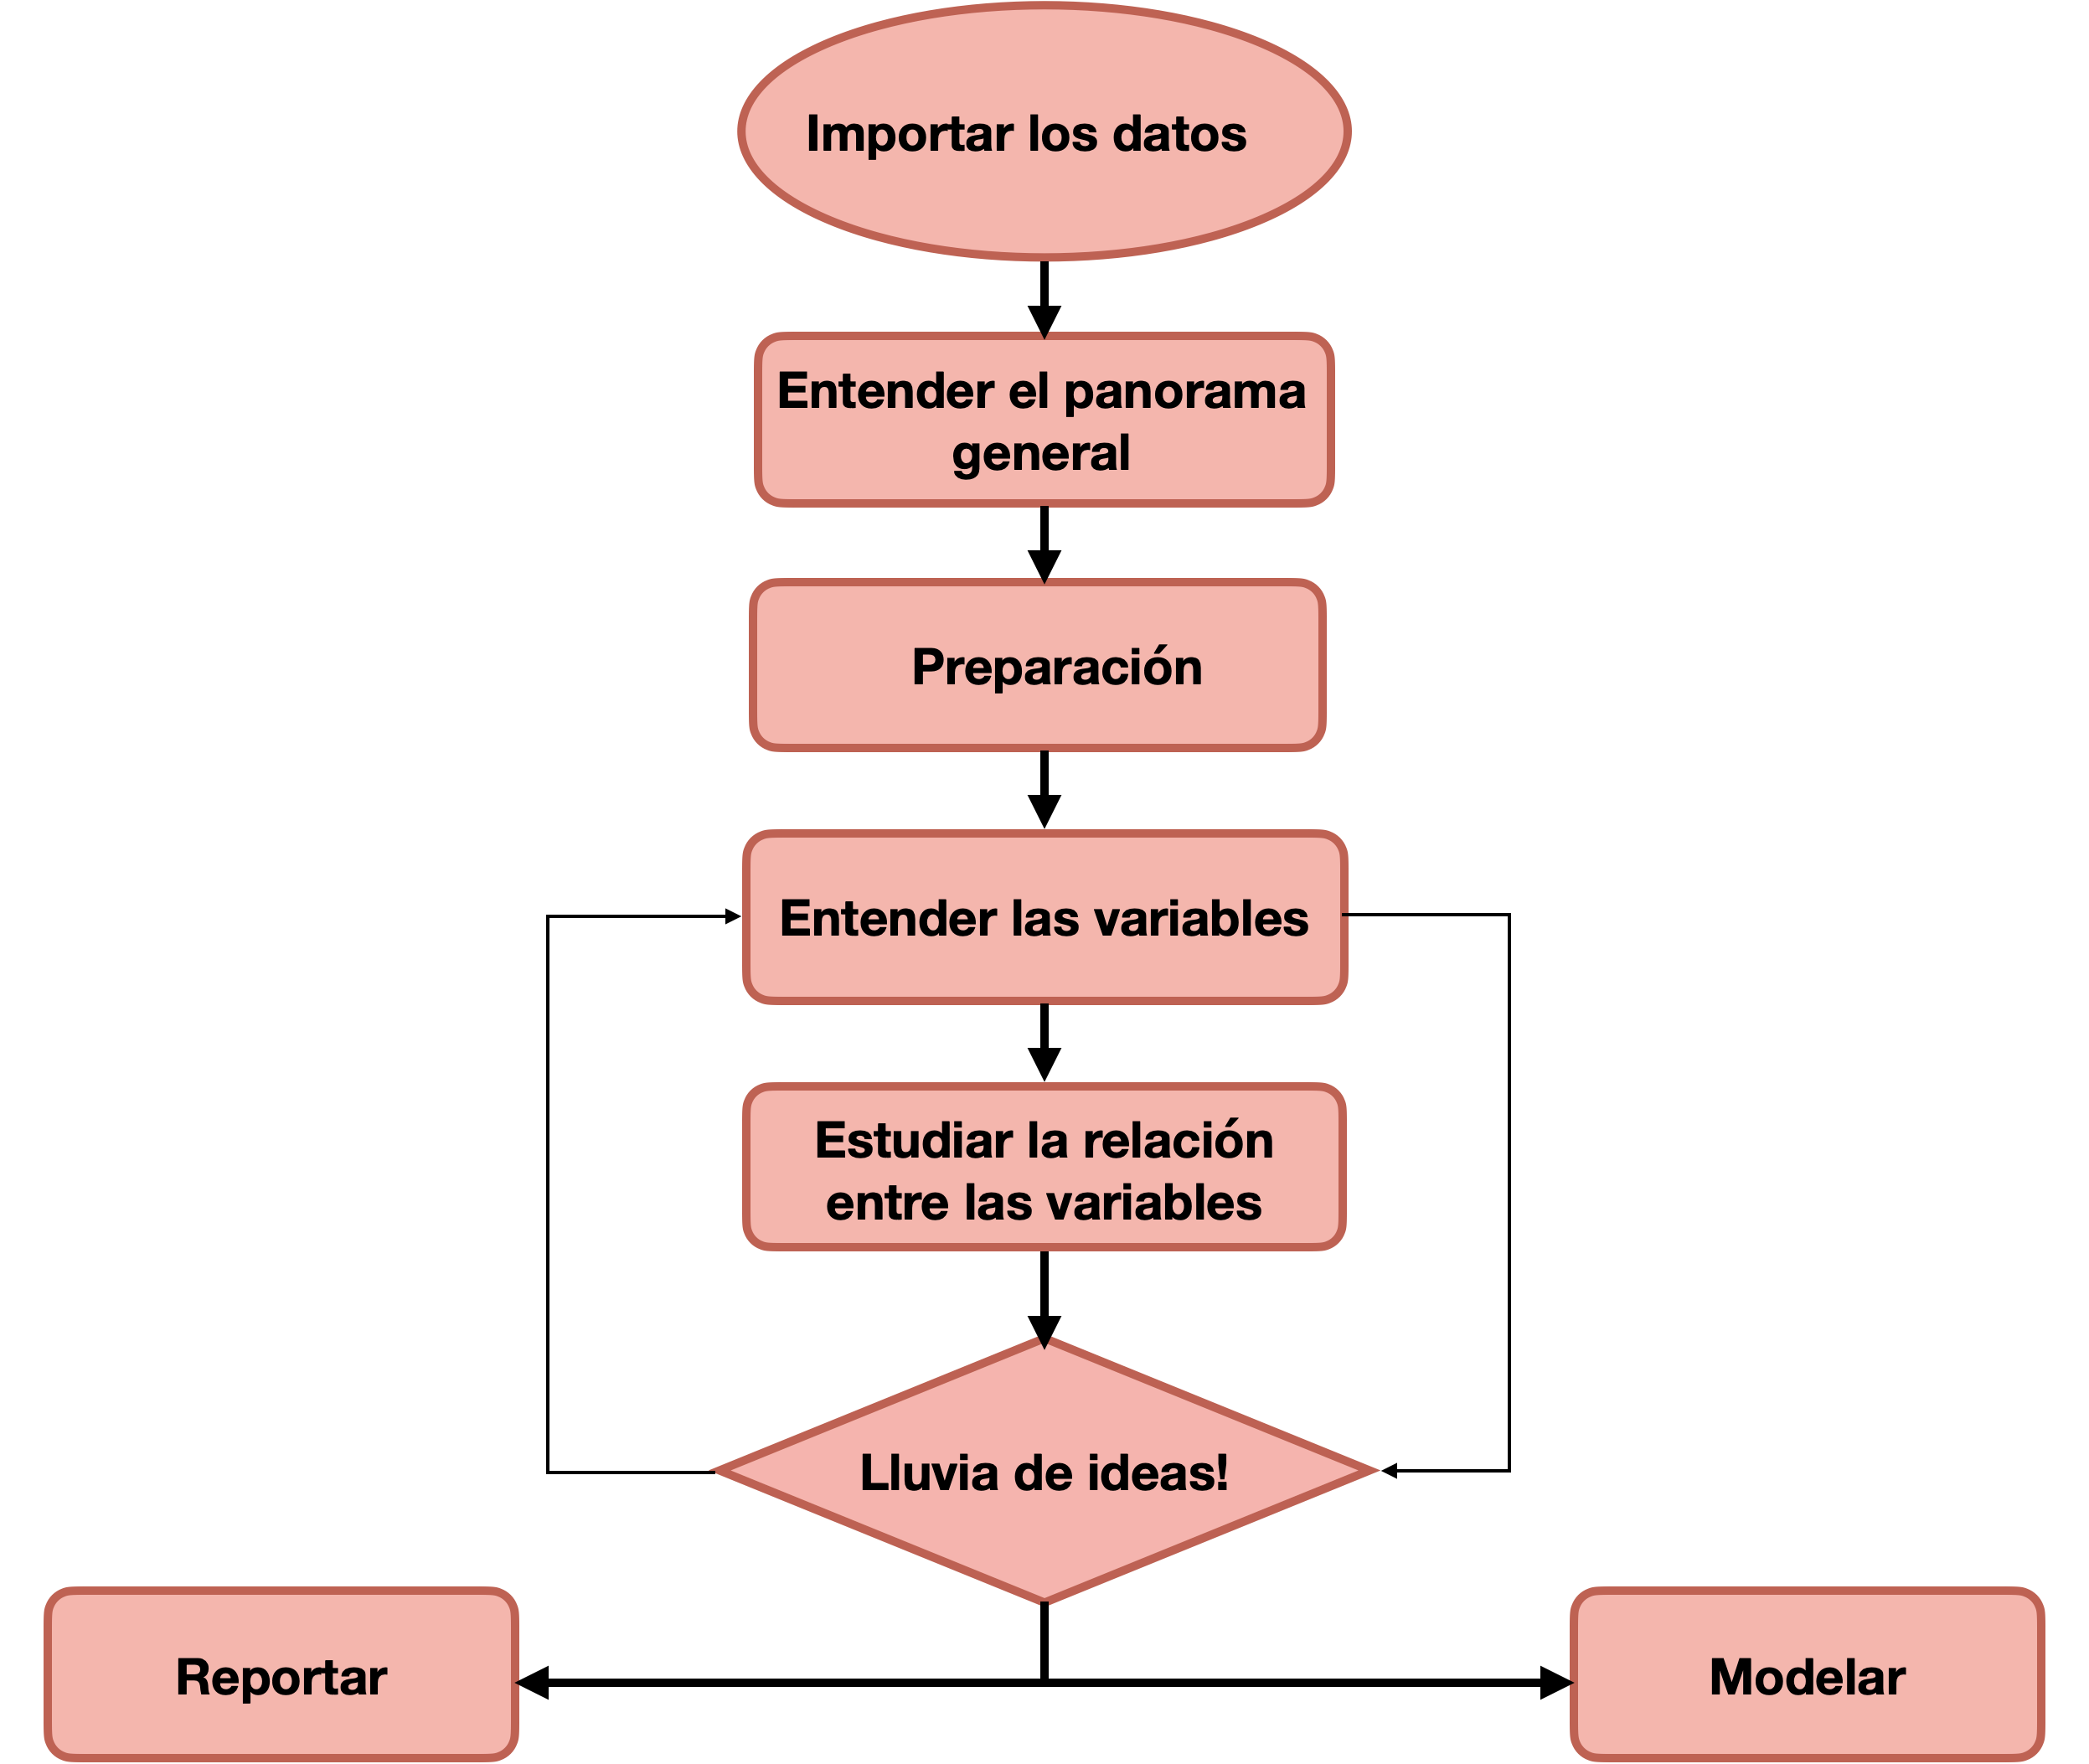

## Análisis Exploratorio de Datos (EDA) con Titanic

En este notebook realizaremos una primera exploración del dataset del Titanic.

La idea **no es construir un modelo todavía**, sino aprender a:

- conocer la estructura de un conjunto de datos,
- identificar variables numéricas y categóricas,
- detectar valores faltantes,
- visualizar distribuciones,
- explorar relaciones entre variables,
- y comenzar a tomar decisiones previas al modelado.

### Pregunta guía

**¿Qué variables parecen estar asociadas con la supervivencia de los pasajeros?**

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline  
#importante para mostrar graficos en el notebook

# en esta línea seteamos un parámetro de seaborn que nos mostrará todos los gráficos con fondo blanco (sin grilla)
sns.set_style('white') 


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/

### Carga del dataset

Comenzamos cargando el archivo y observando sus primeras filas.

In [6]:
titanic=pd.read_csv('titanic.csv') 

In [13]:
titanic.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


Descripción de las características:
- **Survived**	Sobrevivencia	0 = No, 1 = Sí
- **Pclass**	Clase	1 = primera, 2 = segunda, 3 = tercera
- **Sex**	Género
- **Age**	Edad en años (puede ser fraccional si es menos de 1)	
- **Sibsp**	número de hermanas u hermanos o cónyuges	
- **Parch**	número de padres/niños
- **Ticket**		
- **Fare**	Tarifa	
- **Cabin**	Número de la Cabina	
- **Embarked**	Puerto de Embarque	C = Cherbourg, Q = Queenstown, S = Southampton


### Inspección inicial de los datos

- **¿Cuántas filas y columnas tiene el dataset?**
- **¿Qué representa cada columna?**
- **¿Qué variable podría ser nuestro objetivo?**
- **¿Qué tipos de datos tenemos?**

<details>
<summary>Ayuda</summary>

Las siguientes funciones de `pandas` pueden ser útiles
- df.shape
- df.info()
- df.describe(include="all")

</details>

### Preguntas para pensar

1. **¿Cuál parece ser la variable objetivo en este problema?**
2. **¿Qué variables son numéricas?**
3. **¿Qué variables son categóricas?**
4. **¿Qué columnas parecen más difíciles de usar directamente en un modelo?**


**Respuesta acá**

### Valores faltantes

Uno de los primeros pasos de un EDA es revisar si faltan datos.

Los valores faltantes pueden afectar tanto el análisis como el entrenamiento de modelos, por lo que es importante detectarlos desde el comienzo.

**Revise las columnas, la cantidad de filas, cuáles columnas tiene datos faltantes, y cuántos datos faltan por cada columna** 

<details>
<summary>Ayuda</summary>

```python
titanic['nombrecolumna'].notna().sum()
```
</details>

**Preguntas**
- **¿Qué variable parece más problemática?**
- **¿Cuál podríamos eliminar?**
- **¿Cuál valdría la pena conservar?**

In [64]:
a=titanic.columns
print("Datos faltantes")
for col in a:
    titanic[col].isnull().sum()
    print(col ,"\033[31m",titanic[col].isnull().sum(),"\033[0m"," datos faltantes")

Datos faltantes
PassengerId  0   datos faltantes
Survived  0   datos faltantes
Pclass  0   datos faltantes
Name  0   datos faltantes
Sex  0   datos faltantes
Age  177   datos faltantes
SibSp  0   datos faltantes
Parch  0   datos faltantes
Ticket  0   datos faltantes
Fare  0   datos faltantes
Cabin  687   datos faltantes
Embarked  2   datos faltantes


## El primer paso es caracterizar la muestra, es decir, responder la pregunta: **¿quiénes eran los pasajeros del titanic?**

Haremos análisis de las variables  categóricas del set de datos para caracterizar a los pasajeros

La función [`catplot`](https://seaborn.pydata.org/generated/seaborn.catplot.html) de seaborn  sirve para graficar variables categóricas (con etiquetas). 

Para contabilizar la variable categórica 'Sex'

In [66]:
titanic['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

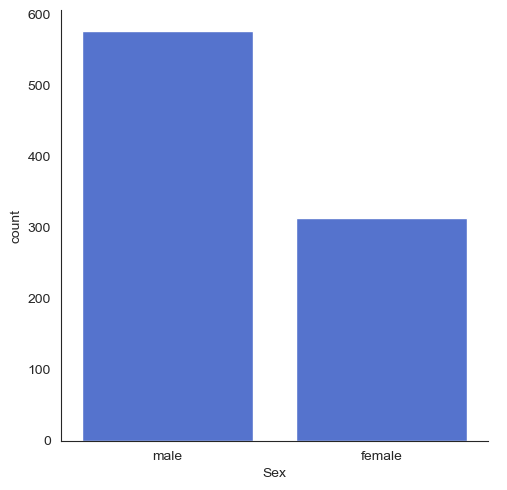

In [68]:
#Los parámetros importantes son los datos de origen, la columna categórica y el tipo de gráfico
plt.figure(figsize=(8,4))
sns.catplot(data=titanic, x='Sex',kind='count', color='royalblue')# queremos contar las entradas en cada categoría
plt.show()

**Explore el resto de las variables categóricas del dataset**

In [ ]:
sns.catplot(...)

<Figure size 800x400 with 0 Axes>

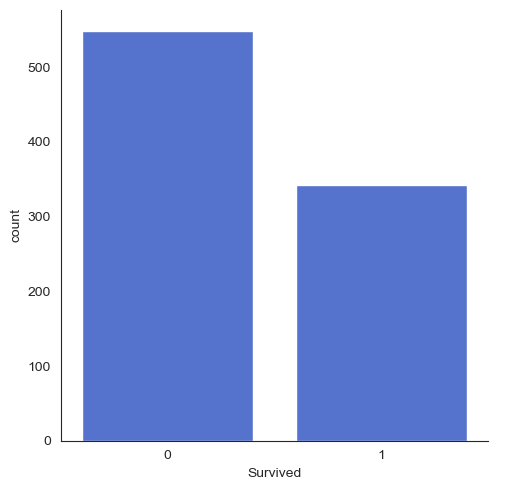

In [74]:
plt.figure(figsize=(8,4))
sns.catplot(data=titanic, x='Survived',kind='count', color='royalblue')# queremos contar las entradas en cada categoría
plt.show()

<Figure size 800x400 with 0 Axes>

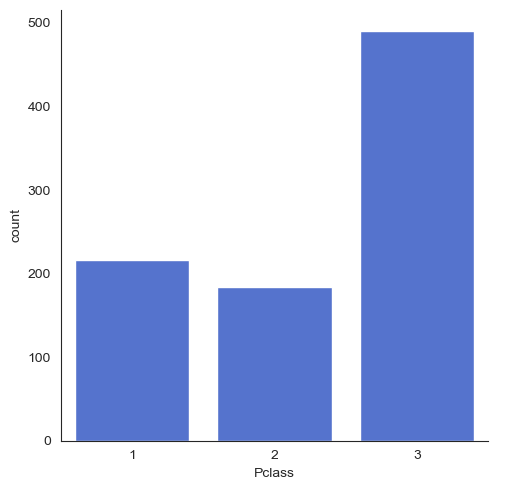

In [76]:
plt.figure(figsize=(8,4))
sns.catplot(data=titanic, x='Pclass',kind='count', color='royalblue')# queremos contar las entradas en cada categoría
plt.show()

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

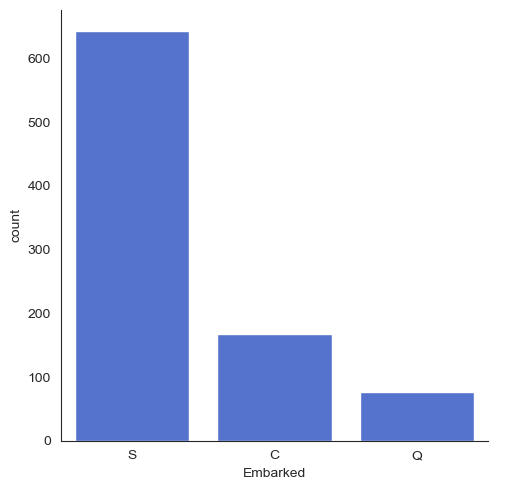

In [72]:
plt.figure(figsize=(8,4))
sns.catplot(data=titanic, x='Embarked',kind='count', color='royalblue')# queremos contar las entradas en cada categoría
plt.show()

Recuerde graficar la variable target, que nos interesaría predecir con un modelo de ML

**Preguntas**
- **¿Hay categorías con muy pocos casos?**
- **¿Hay alguna variable claramente desbalanceada?**
- **¿Esto podría influir en el análisis posterior?**

Ahora veremos las variables numéricas del dataset. Primero entenderemos la variable `Age`. Nos interesa detectar forma de la distribución, posible asimetría (skewness), presencia de outliers y valores faltantes

<Figure size 800x400 with 0 Axes>

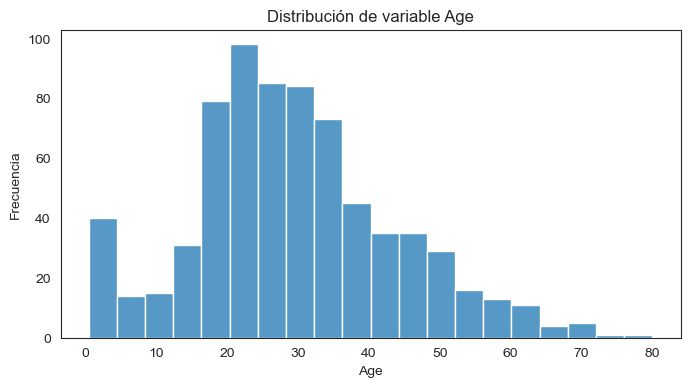

In [8]:
num_bins=20  #Elija un número apropiado
 
plt.figure(figsize=(8,4))
sns.histplot(titanic["Age"], bins=num_bins, kde=False)
plt.title("Distribución de variable Age")
plt.xlabel("Age")
plt.ylabel("Frecuencia")
plt.show()

### Preguntas para discutir

- **¿La distribución parece simétrica?**
- **¿Hay edades extremas?**
- **Si debemos imputar esta variable, ¿usarías media o mediana?**

**Respuestas acá**

**Repita el análisis para el resto de las variables numéricas**

**Preguntas:**
- **¿La variable `Fare` parece sesgada?**
- **¿Hay outliers?**
- **¿Podría ser útil aplicar una transformación en etapas posteriores?**

In [92]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

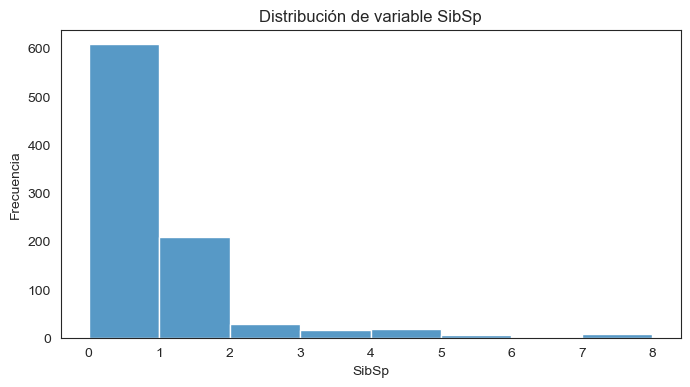

In [22]:
num_bins=8  
 
plt.figure(figsize=(8,4))
sns.histplot(titanic["SibSp"], bins=num_bins, kde=False)
plt.title("Distribución de variable SibSp")
plt.xlabel("SibSp")
plt.ylabel("Frecuencia")
plt.show()

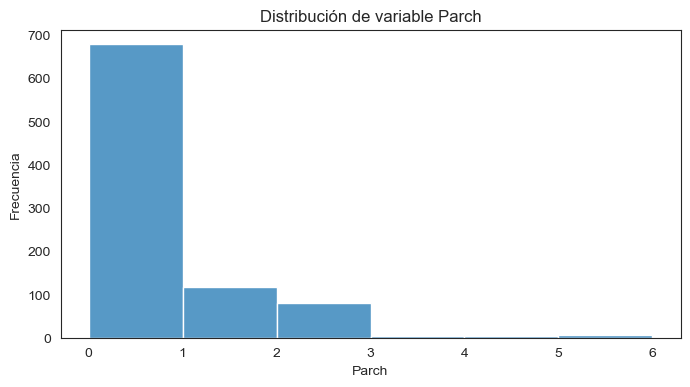

In [118]:
num_bins=6  
 
plt.figure(figsize=(8,4))
sns.histplot(titanic["Parch"], bins=num_bins, kde=False)
plt.title("Distribución de variable Parch")
plt.xlabel("Parch")
plt.ylabel("Frecuencia")
plt.show()

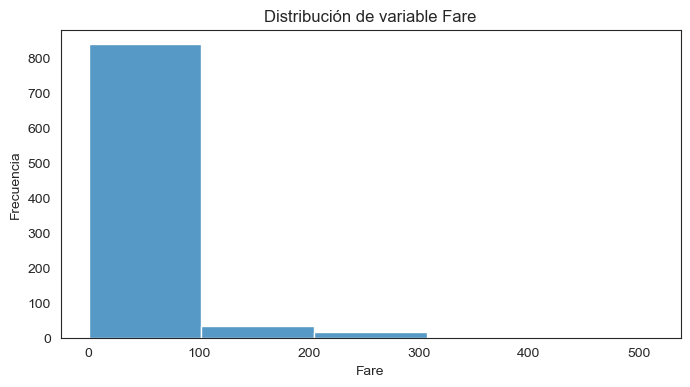

In [120]:
num_bins=5  
 
plt.figure(figsize=(8,4))
sns.histplot(titanic["Fare"], bins=num_bins, kde=False)
plt.title("Distribución de variable Fare")
plt.xlabel("Fare")
plt.ylabel("Frecuencia")
plt.show()

### Análisis Bivariado

Ahora revisaremos las relaciones entre la variable `Survived` y otras variables

Comparemos la proporción de supervivencia respecto a la variable `Sex`

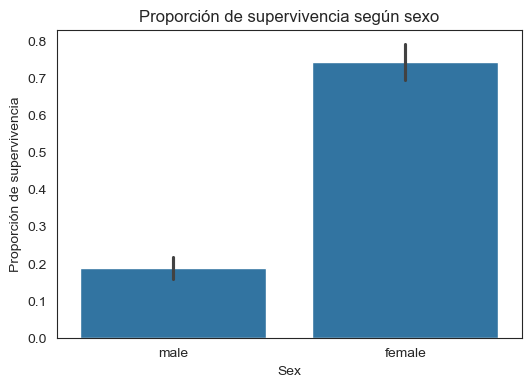

In [122]:
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Sex", y="Survived", estimator=np.mean)
plt.title("Proporción de supervivencia según sexo")
plt.xlabel("Sex")
plt.ylabel("Proporción de supervivencia")
plt.show()

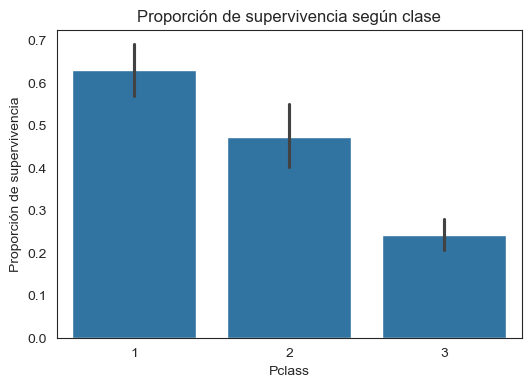

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Pclass", y="Survived", estimator=np.mean)
plt.title("Proporción de supervivencia según clase")
plt.xlabel("Pclass")
plt.ylabel("Proporción de supervivencia")
plt.show()


Este gráfico permite comparar la fracción promedio de pasajeros que sobrevivieron en cada categoría.

### Preguntas

- **¿Parece haber una diferencia importante?**
- **¿Esto implica causalidad?**
- **¿Qué otras variables podrían estar influyendo también?**

**Respuesta acá**

Incluso podemos hacer el mismo análisis pero comparar interacciones entre variables, por ejemplo `Sex` y `P_class`

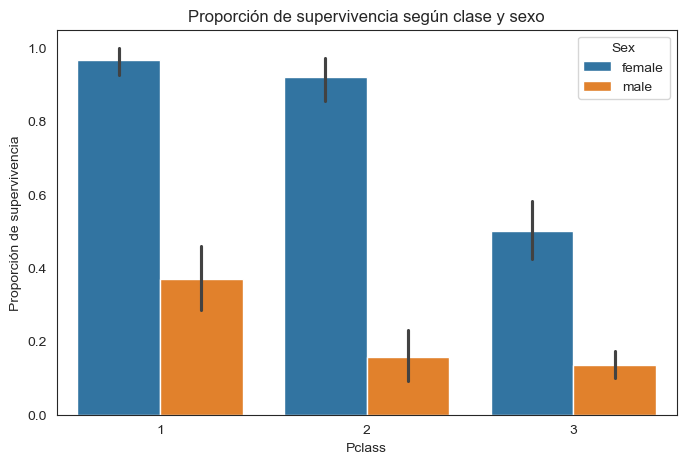

In [124]:
plt.figure(figsize=(8,5))
sns.barplot(data=titanic, x="Pclass", y="Survived", hue="Sex", estimator=np.mean)
plt.title("Proporción de supervivencia según clase y sexo")
plt.xlabel("Pclass")
plt.ylabel("Proporción de supervivencia")
plt.show()

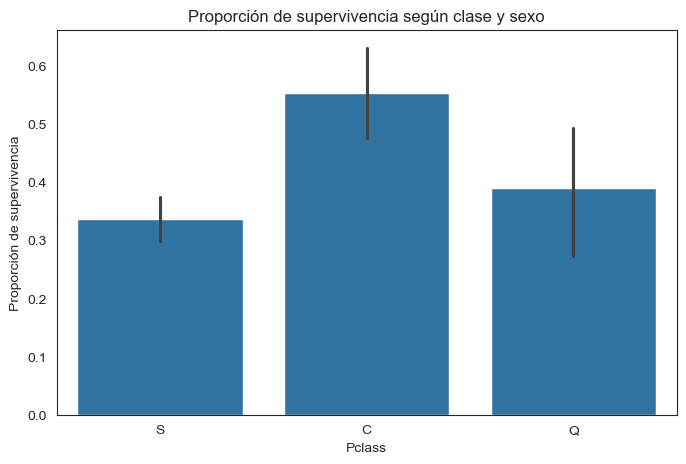

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(data=titanic, x="Embarked", y="Survived", estimator=np.mean)
plt.title("Proporción de supervivencia según lugar de embarque")
plt.xlabel("Embarked")
plt.ylabel("Proporción de supervivencia")
plt.show()

- **¿Sigue siendo importante el sexo dentro de cada clase?**
- **¿Sigue siendo importante la clase dentro de cada sexo?**
- **¿Qué nos dice esto sobre la interacción entre variables?**

**Compare otras variables con la supervivencia (edad, clase, tarifa, etc) y resuma sus observaciones**

### Correlación entre variables numéricas

La matriz de correlación puede servir para detectar relaciones lineales entre variables numéricas.



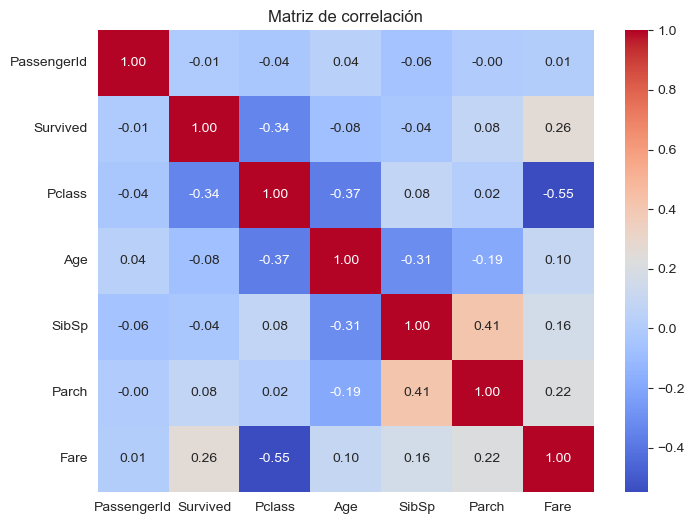

In [126]:
corr = titanic.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

**Cuidado al interpretar!!**

- La correlación de Pearson mide relaciones lineales.
- Una correlación baja no implica que una variable no sea útil.
- `Survived` es binaria, así que esta matriz debe interpretarse con precaución.

## No toda visualización es igual de útil

A veces un gráfico puede hacerse, pero eso no significa que sea la mejor opción para interpretar una relación.

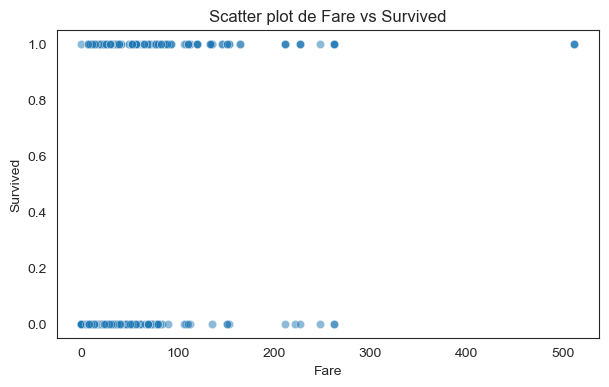

In [128]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=titanic, x="Fare", y="Survived", alpha=0.5)
plt.title("Scatter plot de Fare vs Survived")
plt.xlabel("Fare")
plt.ylabel("Survived")
plt.show()

**Pregunta**

**¿Te parece que este gráfico ayuda realmente a entender la relación entre ambas variables? ¿Por qué podría no ser la mejor opción?**

Hay dos variables que no analizamos: SibSp y Parch.
¿Qué creen que representan?

In [130]:
titanic[['SibSp','Parch']].describe()

,SibSp,Parch
count,891.000000,891.000000
mean,0.523008,0.381594
std,1.102743,0.806057
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,8.000000,6.000000


Grafique la relación entre ambas variables y Survived


- **¿tiene sentido usarlas tal cual?**
- **¿son fáciles de interpretar?**
- **¿qué problema ven?**

¿Les parece más útil tener dos variables…
o una que represente tamaño de familia?

Cree una nueva variable que use la información de estas otras dos y represente mejor la información. Grafique la relación de esta variable con Survived

In [12]:
Sib=titanic.SibSp
Par=titanic.Parch
fam=[]
for a,b in zip(Sib,Par):
    fam.append(a+b)


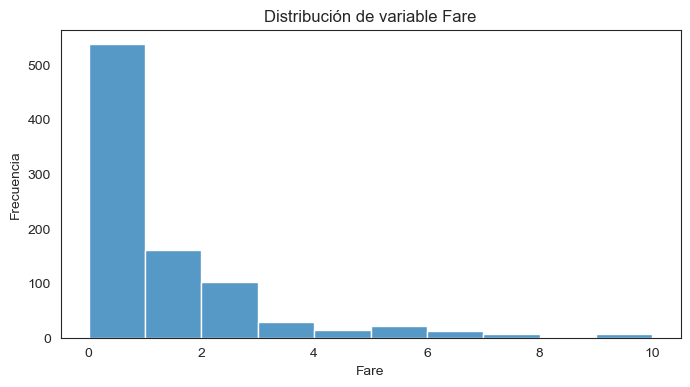

In [18]:
num_bins=10  
 
plt.figure(figsize=(8,4))
sns.histplot(fam, bins=num_bins, kde=False)
plt.title("Distribución de variable Fare")
plt.xlabel("Fare")
plt.ylabel("Frecuencia")
plt.show()

<Figure size 800x500 with 0 Axes>

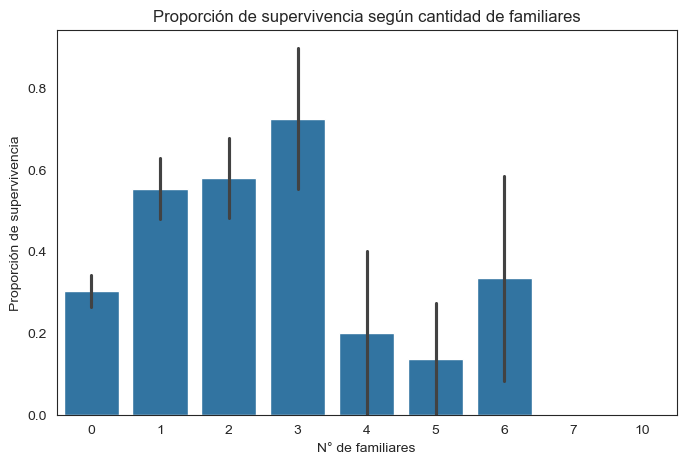

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=titanic, x=fam, y="Survived", estimator=np.mean)
plt.title("Proporción de supervivencia según cantidad de familiares")
plt.xlabel("N° de familiares")
plt.ylabel("Proporción de supervivencia")
plt.show()

## Conclusión

El EDA no consiste solo en visualizar datos.
El objetivo es **entender los datos y tomar decisiones informadas antes del modelado**.
